In [1]:
"""
ANTICIPACIÓN DE JUGADAS PELIGROSAS
Modelos Secuenciales (LSTM vs GRU) - Análisis Táctico
"""

import sys
import os

notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from src.data.loader import StatsBombLoader
from src.data.preprocessing import PassPreprocessor
from src.models.sequential import SequentialTacticalModel
from src.models.evaluation import ModelEvaluator

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print(" Librerías cargadas")
print("ANTICIPACIÓN DE JUGADAS PELIGROSAS")
print(" Modelos Secuenciales: LSTM vs GRU")

 TensorFlow cargado: 2.21.0
 Librerías cargadas
ANTICIPACIÓN DE JUGADAS PELIGROSAS
 Modelos Secuenciales: LSTM vs GRU


In [2]:
# CARGA Y PREPARACIÓN DE DATOS DE EVENTOS

print("\n CARGANDO DATOS DE EVENTOS")
loader = StatsBombLoader()

SEASONS = [
    {'season_id': 90, 'season_name': '2020/2021'},
    {'season_id': 42, 'season_name': '2019/2020'},
    {'season_id': 4,  'season_name': '2018/2019'},
]

COMPETITION_ID = 11

all_events = []

for season in SEASONS:
    print(f"\n Cargando temporada {season['season_name']}...")
    
    try:
        matches = loader.get_matches(
            competition_id=COMPETITION_ID,
            season_id=season['season_id']
        )
        
        barca_matches = matches[
            (matches['home_team'] == 'Barcelona') |
            (matches['away_team'] == 'Barcelona')
        ]
        
        for _, match_row in barca_matches.iterrows():
            try:
                events, _ = loader.load_match_data(match_row['match_id'])
                events['season'] = season['season_name']
                events['match_id_ref'] = match_row['match_id']
                all_events.append(events)
            except Exception as e:
                print(f"   Error partido {match_row['match_id']}: {e}")
                
        print(f"   {len(barca_matches)} partidos cargados")
        
    except Exception as e:
        print(f"   Error temporada {season['season_name']}: {e}")

df_events = pd.concat(all_events, ignore_index=True)

print(f" DATOS CARGADOS:")
print(f"  - Total eventos:    {len(df_events)}")
print(f"  - Tipos de evento:  {df_events['type'].nunique()}")
print(f"   - Partidos únicos:  {df_events['match_id_ref'].nunique()}")


 CARGANDO DATOS DE EVENTOS
 Data directory: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw

 Cargando temporada 2020/2021...
 Partidos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\matches_11_90.csv
 Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_3773386.csv
 Partido 3773386:
   - Total eventos: 3891
   - Total pases: 1118
 Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_3773565.csv
 Partido 3773565:
   - Total eventos: 3775
   - Total pases: 1153
 Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_3773457.csv
 Partido 3773457:
   - Total eventos: 4205
   - Total pases: 1201
 Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_3773631.csv
 Partido 3773631:
   - Total eventos: 4004
   - Total pases: 1184
 Eventos guardados en: C:\Users\xurzy\Desktop

In [3]:
# CONSTRUCCIÓN DE SECUENCIAS Y ETIQUETADO DE JUGADAS PELIGROSAS

print("\n CONSTRUYENDO SECUENCIAS DE JUGADAS...")
print("Nota- Se excluyen los tiros del input para que el modelo aprenda a detectar peligro ANTES de que ocurra el tiro")
WINDOW_FUTURE = 5

def extract_event_features(event_row):
    """
    Extraemos features numéricas de un evento individual.
    Nota: Tiros excluidos del tipo de evento para evitar
    que el modelo detecte el tiro en vez de predecirlo.
    """
    features = {}

    features['minute'] = event_row.get('minute', 0)
    features['second'] = event_row.get('second', 0)
    features['period'] = event_row.get('period', 1)

    # Exlcuyo tiros
    event_types = {
        'Pass': 1, 'Carry': 2, 'Dribble': 3,
        'Ball Receipt*': 4, 'Pressure': 5, 'Other': 0
    }
    features['event_type'] = event_types.get(
        event_row.get('type', 'Other'), 0
    )

    location = event_row.get('location', None)
    if isinstance(location, list) and len(location) == 2:
        features['loc_x']       = location[0]
        features['loc_y']       = location[1]
        features['dist_center'] = np.sqrt(
            (location[0] - 60)**2 + (location[1] - 40)**2
        )
        features['dist_goal']   = np.sqrt(
            (location[0] - 120)**2 + (location[1] - 40)**2
        )
    else:
        features['loc_x']       = 60.0
        features['loc_y']       = 40.0
        features['dist_center'] = 0.0
        features['dist_goal']   = 60.0

    features['zona_ataque']  = 1 if features['loc_x'] > 80 else 0
    features['zona_media']   = 1 if 40 <= features['loc_x'] <= 80 else 0
    features['zona_defensa'] = 1 if features['loc_x'] < 40 else 0

    if event_row.get('type') == 'Pass':
        features['pass_success'] = 1 if pd.isna(
            event_row.get('pass_outcome')
        ) else 0
    else:
        features['pass_success'] = 0

    return features

print(" Construyendo secuencias (puede tardar unos minutos)...")

sequences = []
labels    = []

for match_id in df_events['match_id_ref'].unique():
    match_events = df_events[
        df_events['match_id_ref'] == match_id
    ].copy().reset_index(drop=True)

    # Filtramos solo Barcelona y excluyendp tiros 
    barca_events = match_events[
        (match_events['team'] == 'Barcelona') &
        (match_events['type'].isin([
            'Pass', 'Carry', 'Dribble',
            'Ball Receipt*', 'Pressure'
            # Sin Shot en el input
        ]))
    ].reset_index(drop=True)

    if len(barca_events) < 15:
        continue


    event_features = []
    for _, row in barca_events.iterrows():
        features = extract_event_features(row)
        event_features.append(features)

    df_feat = pd.DataFrame(event_features).fillna(0)
    X_match = df_feat.values

    all_barca = match_events[
        match_events['team'] == 'Barcelona'
    ].reset_index(drop=True)

    n = len(X_match)
    for i in range(n - WINDOW_FUTURE):
        # Tiempo del último evento de la secuencia
        last_time = barca_events.iloc[i + WINDOW_FUTURE - 1]['minute'] * 60 + \
                    barca_events.iloc[i + WINDOW_FUTURE - 1].get('second', 0)

        # Buscamos tiros en los próximos 30 segundos en el partido completo
        future_shots = all_barca[
            (all_barca['type'] == 'Shot') &
            (all_barca['minute'] * 60 + all_barca.get('second', 0) > last_time) &
            (all_barca['minute'] * 60 + all_barca.get('second', 0) <= last_time + 30)
        ]

        is_dangerous = int(len(future_shots) > 0)
        labels.append(is_dangerous)
        sequences.append(X_match[i:i + WINDOW_FUTURE])

X_sequences = np.array(sequences)
y_labels    = np.array(labels)

print(f"\n SECUENCIAS CONSTRUIDAS:")
print(f"   - Total secuencias:      {len(X_sequences)}")
print(f"   - Shape:                 {X_sequences.shape}")
print(f"   - Jugadas peligrosas:    {y_labels.sum()} ({y_labels.mean()*100:.1f}%)")
print(f"   - Jugadas no peligrosas: {(1-y_labels).sum()} ({(1-y_labels).mean()*100:.1f}%)")


 CONSTRUYENDO SECUENCIAS DE JUGADAS...
Nota- Se excluyen los tiros del input para que el modelo aprenda a detectar peligro ANTES de que ocurra el tiro
 Construyendo secuencias (puede tardar unos minutos)...

 SECUENCIAS CONSTRUIDAS:
   - Total secuencias:      226687
   - Shape:                 (226687, 5, 12)
   - Jugadas peligrosas:    26406 (11.6%)
   - Jugadas no peligrosas: 200281 (88.4%)


In [4]:
# SPLIT Y ESCALADO DE DATOS

print("\n PREPARANDO DATOS PARA ENTRENAMIENTO")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_sequences, y_labels,
    test_size=0.25,
    random_state=42,
    stratify=y_labels
)

# Escalamos (fit en train, transform en ambos)
n_train, seq_len, n_features = X_train.shape

scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, seq_len, n_features)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape[0], seq_len, n_features)

# Split de validación desde train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f" Datos preparados:")
print(f"   - Train:      {X_tr.shape[0]} secuencias")
print(f"   - Validación: {X_val.shape[0]} secuencias")
print(f"   - Test:       {X_test_scaled.shape[0]} secuencias")
print(f"   - Features:   {n_features}")


 PREPARANDO DATOS PARA ENTRENAMIENTO
 Datos preparados:
   - Train:      136012 secuencias
   - Validación: 34003 secuencias
   - Test:       56672 secuencias
   - Features:   12


In [5]:
# BALANCEO DE CLASES

from sklearn.utils import resample

print("\n  BALANCEANDO CLASES...")
print(f"   Antes → Clase 0: {(y_tr==0).sum()} | Clase 1: {(y_tr==1).sum()}")

# Separamos clases
X_train_2d_flat = X_tr.reshape(len(X_tr), -1)

idx_0 = np.where(y_tr == 0)[0]
idx_1 = np.where(y_tr == 1)[0]

idx_1_upsampled = resample(
    idx_1,
    replace=True,
    n_samples=len(idx_0),
    random_state=42
)

idx_balanced = np.concatenate([idx_0, idx_1_upsampled])
np.random.shuffle(idx_balanced)

X_tr_bal = X_tr[idx_balanced]
y_tr_bal = y_tr[idx_balanced]

print(f"   Después → Clase 0: {(y_tr_bal==0).sum()} | Clase 1: {(y_tr_bal==1).sum()}")
print(f" Clases balanceadas")


  BALANCEANDO CLASES...
   Antes → Clase 0: 120169 | Clase 1: 15843
   Después → Clase 0: 120169 | Clase 1: 120169
 Clases balanceadas



 COMPARATIVA: LSTM vs GRU

 Entrenando LSTM...

 Entrenando LSTM (classification)...
   - Input shape: (240338, 5, 12)
   - Epochs: 20 | Batch: 64

 Modelo LSTM construido:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 5, 64)               │          19,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 5, 64)               │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,601 (131.25 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.6073 - loss: 0.6600 - val_accuracy: 0.6094 - val_loss: 0.6599 - learning_rate: 0.0010
Epoch 2/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.6270 - loss: 0.6448 - val_accuracy: 0.6072 - val_loss: 0.6636 - learning_rate: 0.0010
Epoch 3/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.6366 - loss: 0.6362 - val_accuracy: 0.6010 - val_loss: 0.6541 - learning_rate: 0.0010
Epoch 4/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.6479 - loss: 0.6260 - val_accuracy: 0.5914 - val_loss: 0.6460 - learning_rate: 0.0010
Epoch 5/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6591 - loss: 0.6137 - val_accuracy: 0.5947 - val_loss: 0.6412 - learning_rate: 0.0010
Epoch 6/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.6714 - loss: 0.6004 - val_accuracy: 0.6019 - val_loss: 0.6288 - learning_rate: 0.0010
Epoch 7/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.6

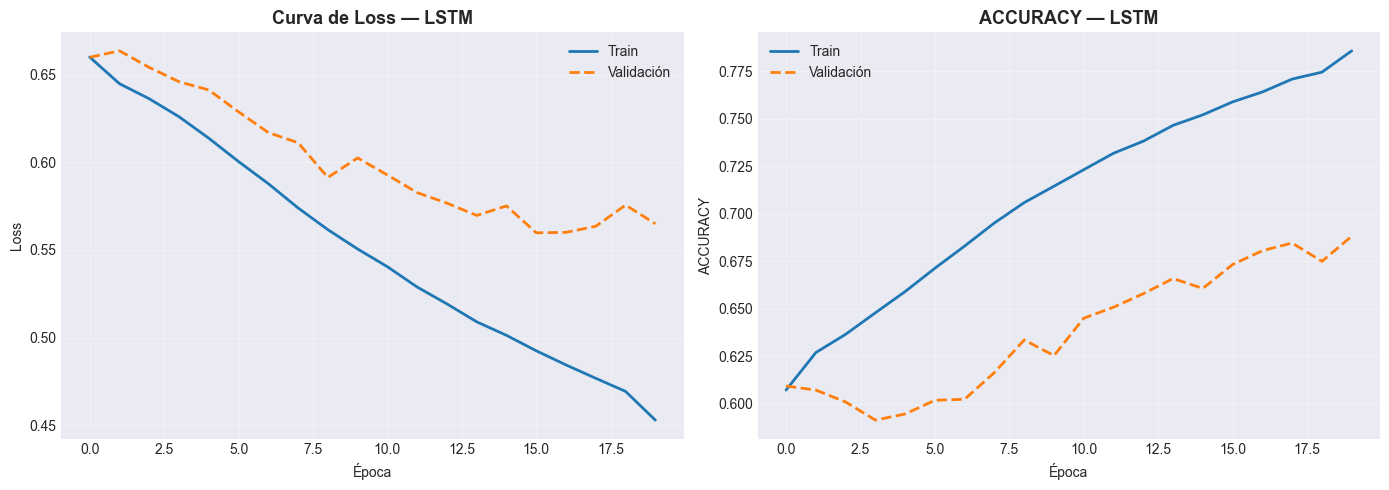


 Entrenando GRU...

 Entrenando GRU (classification)...
   - Input shape: (240338, 5, 12)
   - Epochs: 20 | Batch: 64

 Modelo GRU construido:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 5, 64)               │          14,976 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 5, 64)               │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,665 (100.25 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.6118 - loss: 0.6573 - val_accuracy: 0.6119 - val_loss: 0.6635 - learning_rate: 0.0010
Epoch 2/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.6257 - loss: 0.6452 - val_accuracy: 0.6148 - val_loss: 0.6509 - learning_rate: 0.0010
Epoch 3/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - accuracy: 0.6334 - loss: 0.6381 - val_accuracy: 0.6035 - val_loss: 0.6502 - learning_rate: 0.0010
Epoch 4/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.6422 - loss: 0.6293 - val_accuracy: 0.6109 - val_loss: 0.6279 - learning_rate: 0.0010
Epoch 5/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6532 - loss: 0.6179 - val_accuracy: 0.5937 - val_loss: 0.6243 - learning_rate: 0.0010
Epoch 6/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.6643 - loss: 0.6057 - val_accuracy: 0.5917 - val_loss: 0.6210 - learning_rate: 0.0010
Epoch 7/20
3756/3756 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6

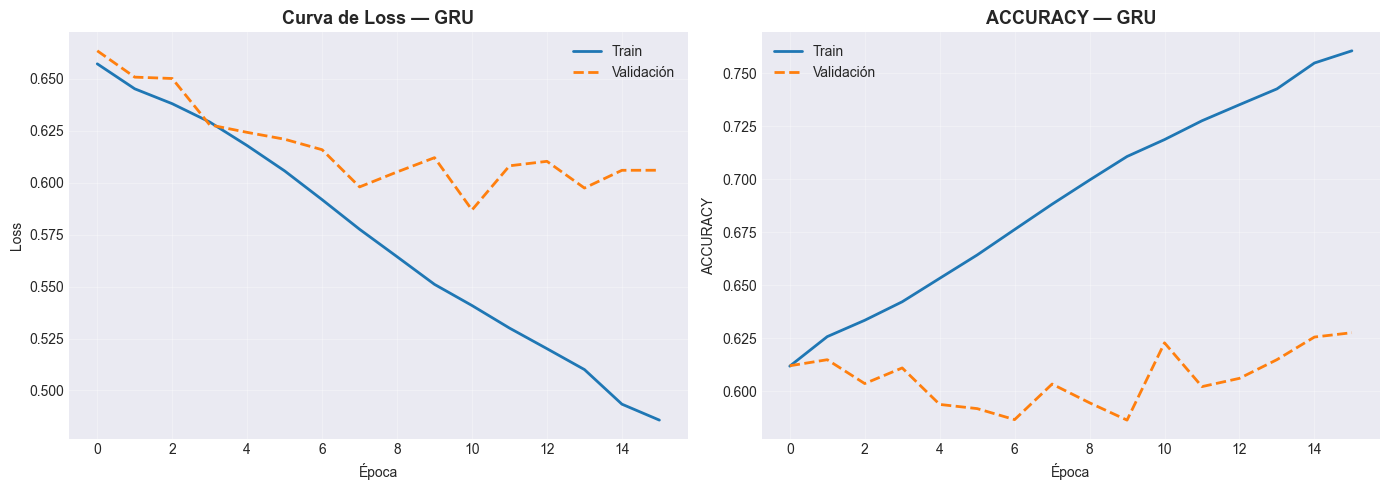



 TABLA COMPARATIVA LSTM vs GRU


,Modelo,Accuracy (Test),F1-Score (Test),AUC-ROC (Test)
0,LSTM,0.6707,0.7290,0.7397
1,GRU,0.6237,0.6911,0.6987


In [6]:
# COMPARATIVA LSTM vs GRU

print("\n COMPARATIVA: LSTM vs GRU")

resultados_seq = []

for model_type in ['lstm', 'gru']:
    print(f"\n{'='*50}")
    print(f" Entrenando {model_type.upper()}...")
    print(f"{'='*50}")
    
    model = SequentialTacticalModel(
        model_type=model_type,
        task='classification',
        sequence_length=seq_len,
        units=64,
        dropout=0.3,
        random_state=42
    )
    
    model.fit(
        X_tr_bal, y_tr_bal,
        X_val=X_val, y_val=y_val,
        epochs=20,
        batch_size=64
    )
    
    # Evaluar
    metrics = model.evaluate(X_test_scaled, y_test)
    
    resultados_seq.append({
        'Modelo': model_type.upper(),
        'Accuracy (Test)': round(metrics['accuracy'], 4),
        'F1-Score (Test)': round(metrics['f1_score'], 4),
        'AUC-ROC (Test)':  round(metrics['auc_roc'], 4),
    })
    
    model.plot_training_history()

# Tabla comparativa
df_seq = pd.DataFrame(resultados_seq)

print("\n\n TABLA COMPARATIVA LSTM vs GRU")
display(df_seq)

In [7]:
# CONCLUSIÓN Y MODELO FINAL

mejor = df_seq.sort_values(['F1-Score (Test)', 'AUC-ROC (Test)'], ascending=False).iloc[0]

print("\n CONCLUSIÓN")

print(f"Mejor modelo: {mejor['Modelo']}")
print(f"  - Accuracy:  {mejor['Accuracy (Test)']:.4f}")
print(f"  - F1-Score:  {mejor['F1-Score (Test)']:.4f}")
print(f"  - AUC-ROC:   {mejor['AUC-ROC (Test)']:.4f}")
print(f"\nJustificación:")
print(f"  - Los modelos secuenciales capturan dependencias temporales")
print(f"    en la secuencia de eventos que modelos clásicos no pueden")
print(f"  - LSTM y GRU son especialmente adecuados porque el desarrollo")
print(f"    de una jugada peligrosa depende de los eventos anteriores")
print(f"  - {mejor['Modelo']} obtiene mejor equilibrio rendimiento/eficiencia")


 CONCLUSIÓN
Mejor modelo: LSTM
  - Accuracy:  0.6707
  - F1-Score:  0.7290
  - AUC-ROC:   0.7397

Justificación:
  - Los modelos secuenciales capturan dependencias temporales
    en la secuencia de eventos que modelos clásicos no pueden
  - LSTM y GRU son especialmente adecuados porque el desarrollo
    de una jugada peligrosa depende de los eventos anteriores
  - LSTM obtiene mejor equilibrio rendimiento/eficiencia



 APLICACIÓN REAL DEL MODELO
Analizando secuencias peligrosas en un partido real de Barcelona

 Preparando modelo LSTM para aplicación...

 Entrenando LSTM (classification)...
   - Input shape: (240338, 5, 12)
   - Epochs: 15 | Batch: 128

 Modelo LSTM construido:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 5, 32)               │           5,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 5, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 5, 32)               │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,665 (37.75 KB)

 Trainable params: 9,569 (37.38 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/15
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.5984 - loss: 0.6657 - val_accuracy: 0.6076 - val_loss: 0.6731 - learning_rate: 0.0010
Epoch 2/15
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6228 - loss: 0.6489 - val_accuracy: 0.6240 - val_loss: 0.6541 - learning_rate: 0.0010
Epoch 3/15
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6272 - loss: 0.6451 - val_accuracy: 0.6027 - val_loss: 0.6571 - learning_rate: 0.0010
Epoch 4/15
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6311 - loss: 0.6416 - val_accuracy: 0.5883 - val_loss: 0.6652 - learning_rate: 0.0010
Epoch 5/15
1870/1878 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6333 - loss: 0.6402
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6354 - loss: 0.6384 - val_accuracy: 0.6108 - val_loss: 0.6562 - learning_rate: 0.0010
Epoch 6/15
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6394 - 

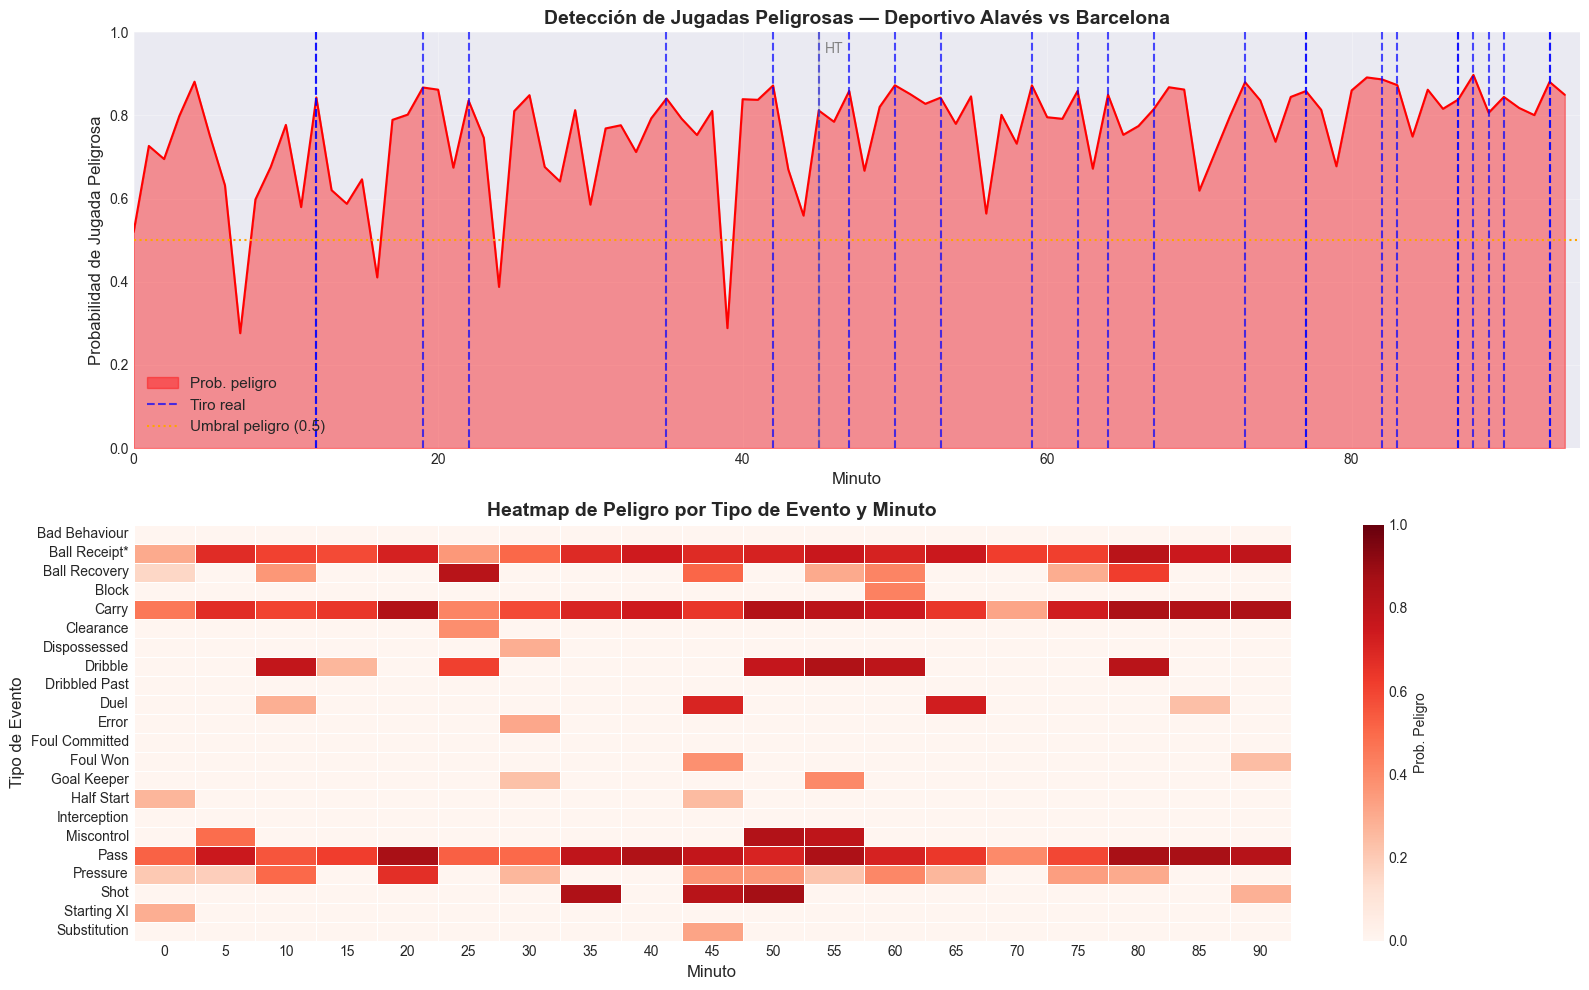


 TOP 10 MOMENTOS MÁS PELIGROSOS DEL PARTIDO:


,minuto,tipo_evento,prob_peligro
0,88,Pass,0.898
1,81,Pass,0.892
2,88,Pass,0.891
3,82,Shot,0.887
4,4,Block,0.881
5,93,Pass,0.881
6,73,Pass,0.880
7,93,Carry,0.877
8,88,Pass,0.877
9,83,Pass,0.873


In [8]:
# APLICACIÓN REAL: ANÁLISIS DE JUGADAS PELIGROSAS EN UN PARTIDO

print("\n APLICACIÓN REAL DEL MODELO")
print("Analizando secuencias peligrosas en un partido real de Barcelona")


# Seleccionar mejor modelo según tabla comparativa
mejor_nombre = df_seq.sort_values(
    ['F1-Score (Test)', 'AUC-ROC (Test)'], ascending=False
).iloc[0]['Modelo']

# Reentrenar el mejor modelo para usarlo en la aplicación
print(f"\n Preparando modelo {mejor_nombre} para aplicación...")

mejor_modelo_demo = SequentialTacticalModel(
    model_type=mejor_nombre.lower(),
    task='classification',
    sequence_length=seq_len,
    units=32,
    dropout=0.3,
    random_state=42
)

mejor_modelo_demo.fit(
    X_tr_bal, y_tr_bal,
    X_val=X_val, y_val=y_val,
    epochs=15,
    batch_size=128
)

print(f" Modelo {mejor_nombre} listo para aplicación")

# Cargamos un partido específico para demostración
loader_demo  = StatsBombLoader()
matches_demo = loader_demo.get_matches(competition_id=11, season_id=90)

barca_demo    = matches_demo[
    (matches_demo['home_team'] == 'Barcelona') |
    (matches_demo['away_team'] == 'Barcelona')
].iloc[0]

match_id_demo = barca_demo['match_id']
home_demo     = barca_demo['home_team']
away_demo     = barca_demo['away_team']
score_home    = barca_demo['home_score']
score_away    = barca_demo['away_score']

print(f"\n Partido: {home_demo} {score_home} - {score_away} {away_demo}")
print(f"   Match ID: {match_id_demo}\n")

# Cargamos los eventos
events_demo, _ = loader_demo.load_match_data(match_id_demo)

# Filtramos los eventos de Barcelona
barca_events_demo = events_demo[
    events_demo['team'] == 'Barcelona'
].reset_index(drop=True)

# Extraemos features
event_features_demo = []
for _, row in barca_events_demo.iterrows():
    feat = extract_event_features(row)
    event_features_demo.append(feat)

df_demo = pd.DataFrame(event_features_demo).fillna(0)
X_demo  = df_demo.values

# Construir secuencias
n_demo = len(X_demo)
X_demo_seq, minutos_demo, tipos_demo = [], [], []

for i in range(n_demo - WINDOW_FUTURE):
    seq = X_demo[i:i + WINDOW_FUTURE]
    X_demo_seq.append(seq)
    minutos_demo.append(barca_events_demo.iloc[i]['minute'])
    tipos_demo.append(barca_events_demo.iloc[i]['type'])

X_demo_arr = np.array(X_demo_seq)

# Escalamos igual que en entrenamiento
n_d, s_d, f_d = X_demo_arr.shape
X_demo_sc = scaler.transform(
    X_demo_arr.reshape(-1, f_d)
).reshape(n_d, s_d, f_d)

# Predecimos probabilidades
proba_demo = mejor_modelo_demo.predict_proba(X_demo_sc)[:, 1]

df_aplicacion = pd.DataFrame({
    'minuto':       minutos_demo,
    'tipo_evento':  tipos_demo,
    'prob_peligro': proba_demo
})

# Secuencias peligrosas (prob > 0.5)
peligrosas = df_aplicacion[df_aplicacion['prob_peligro'] > 0.5]
print(f" Secuencias analizadas:  {len(df_aplicacion)}")
print(f"  Secuencias peligrosas: {len(peligrosas)} ({len(peligrosas)/len(df_aplicacion)*100:.1f}%)")

# Tiros reales para comparar
tiros_reales = events_demo[
    (events_demo['team'] == 'Barcelona') &
    (events_demo['type'] == 'Shot')
]['minute'].tolist()

print(f" Tiros reales de Barcelona: {len(tiros_reales)} (minutos: {tiros_reales})")

#  Visualización 
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Gráfico 1: Probabilidad de peligro por minuto
minutos_uniq = df_aplicacion.groupby('minuto')['prob_peligro'].max().reset_index()

axes[0].fill_between(
    minutos_uniq['minuto'],
    minutos_uniq['prob_peligro'],
    alpha=0.4, color='red', label='Prob. peligro'
)
axes[0].plot(
    minutos_uniq['minuto'],
    minutos_uniq['prob_peligro'],
    color='red', linewidth=1.5
)

# Marcamos los tiros reales
for tiro in tiros_reales:
    axes[0].axvline(
        x=tiro, color='blue', linestyle='--',
        alpha=0.7, linewidth=1.5
    )

axes[0].axvline(
    x=tiros_reales[0] if tiros_reales else 0,
    color='blue', linestyle='--',
    alpha=0.7, linewidth=1.5,
    label='Tiro real'
)
axes[0].axhline(
    y=0.5, color='orange', linestyle=':',
    linewidth=1.5, label='Umbral peligro (0.5)'
)
axes[0].axvline(x=45, color='gray', linestyle='-', alpha=0.3)
axes[0].set_xlabel('Minuto', fontsize=12)
axes[0].set_ylabel('Probabilidad de Jugada Peligrosa', fontsize=12)
axes[0].set_title(
    f'Detección de Jugadas Peligrosas — {home_demo} vs {away_demo}',
    fontsize=14, fontweight='bold'
)
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, 95)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].text(46, 0.95, 'HT', fontsize=10, color='gray', ha='center')

# Gráfico 2: Heatmap de peligro por tipo de evento y minuto
pivot = df_aplicacion.pivot_table(
    index='tipo_evento',
    columns='minuto',
    values='prob_peligro',
    aggfunc='max'
).fillna(0)

cols_5min = [c for c in pivot.columns if c % 5 == 0]
pivot_5   = pivot[cols_5min]

sns.heatmap(
    pivot_5,
    ax=axes[1],
    cmap='Reds',
    vmin=0, vmax=1,
    cbar_kws={'label': 'Prob. Peligro'},
    linewidths=0.5
)
axes[1].set_title(
    'Heatmap de Peligro por Tipo de Evento y Minuto',
    fontsize=14, fontweight='bold'
)
axes[1].set_xlabel('Minuto', fontsize=12)
axes[1].set_ylabel('Tipo de Evento', fontsize=12)

plt.tight_layout()
plt.show()

# Resumen de fases peligrosas 
print(f"\n TOP 10 MOMENTOS MÁS PELIGROSOS DEL PARTIDO:")

top_momentos = df_aplicacion.nlargest(10, 'prob_peligro')[
    ['minuto', 'tipo_evento', 'prob_peligro']
].reset_index(drop=True)
top_momentos['prob_peligro'] = top_momentos['prob_peligro'].apply(
    lambda x: f"{x:.3f}"
)
display(top_momentos)